### Object Detection (물체 탐지)
- 각각의 대상들에 대해서 그 위치와 레이블을 분류
- 이미지의 유형과 함께 경계 상자(bounding box)의 좌표를 함께 출력

### 손실 함수
- 경계 상자의 좌표 (연속 변수)
- 물체의 분류 (범주형 변수)

### Ultralytics YOLO 활용 실습
- Ultralytics: 다양한 YOLO 모델을 지원하는 PyTorch 기반 프레임워크
- COCO 데이터셋으로 사전학습된 모델 제공, 학습/평가/추론이 간단함

In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21  Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 143.0/476.1 GB disk)


In [16]:
import cv2
import numpy as np
from PIL import Image

def show(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

In [2]:
from ultralytics import YOLO # 임포트
model = YOLO("yolo11n.pt") # 모델 로딩

# 이미지 파일에 적용
results = model('../data/bus_stop.jpg')


image 1/1 c:\Users\rapa\Documents\\11__\00_autoever_sw_school\DAY5\..\data\bus_stop.jpg: 448x640 5 persons, 3 bicycles, 1 car, 1 bus, 45.1ms
Speed: 4.3ms preprocess, 45.1ms inference, 10.1ms postprocess per image at shape (1, 3, 448, 640)


In [22]:
# OpenCV에서 파일을 불러들여서 모델에 적용하는 방법
import cv2
img = cv2.imread("../data/bus_stop.jpg") # OpenCV로 파일 열기

In [23]:
results = model(img) # 이미지에 모델 적용


0: 448x640 5 persons, 3 bicycles, 1 car, 1 bus, 21.1ms
Speed: 2.6ms preprocess, 21.1ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)


In [24]:
# 일정 수준 이상의 확률을 가진 물체만 탐지하는 방법
results = model(img, conf=0.8) # 확률 80% 이상인 물체만 탐지


0: 448x640 3 persons, 1 bus, 21.0ms
Speed: 2.8ms preprocess, 21.0ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


tensor([[445.8258, 218.9108, 513.3097, 399.9887],
        [ 30.0637, 227.2532, 147.6289, 452.7263],
        [544.8667,  79.1708, 798.4809, 394.5335],
        [558.7251, 205.5347, 624.3138, 398.4546]], device='cuda:0')
tensor([0., 0., 5., 0.], device='cuda:0')
tensor([0.8868, 0.8785, 0.8704, 0.8468], device='cuda:0')


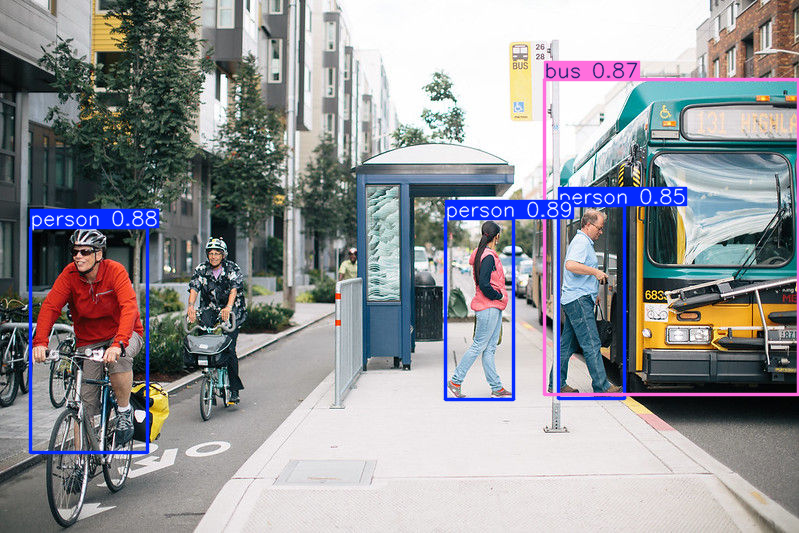

In [25]:
# 결과 출력 (바운딩 박스, 클래스, 신뢰도)
for r in results:
    print(r.boxes.xyxy) # 바운딩 박스 좌표
    print(r.boxes.cls) # 클래스 ID
    print(r.boxes.conf) # 신뢰도 = 물체의 확률 × 상자의 정확도

show(results[0].plot())

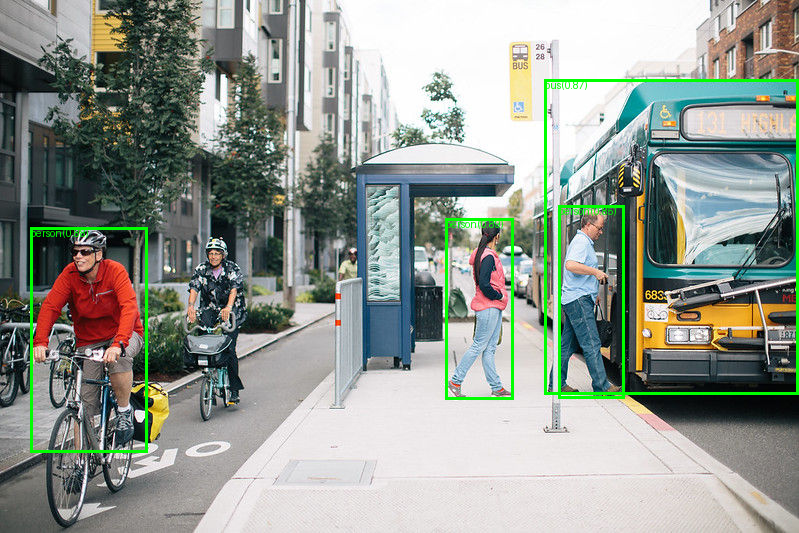

In [ ]:
# 결과 시각화
from PIL import Image, ImageDraw, ImageFont

# 글꼴 설정: 같은 폴더에 ttf 글꼴 파일이 있어야 함. 없으면 기본 글꼴 사용
try:
    font = ImageFont.truetype("NanumGothic.ttf", 20)
except IOError:
    font = ImageFont.load_default()

# 결과를 그릴 새 이미지 만듦
img_bbox = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
draw = ImageDraw.Draw(img_bbox)

# 결과
result = results[0] # 이미지가 하나이므로 결과도 하나
boxes = result.boxes # 모든 경계상자의 정보

for i, box in enumerate(boxes): # 모든 경계 상자에 다음의 작업을 수행
    xyxy = box.xyxy[0].cpu().numpy() # 좌표값 (x1, y1, x2, y2)
    cls_id = int(box.cls[0].cpu().numpy()) # 클래스 ID
    confidence = float(box.conf[0].cpu().numpy()) # 확률
    x1, y1, x2, y2 = xyxy.astype(int) # 좌표값 언패킹
    draw.rectangle([x1, y1, x2, y2], outline="#00FF00", width=3) # 초록색 경계 상자
    label = f"{result.names[cls_id]}({confidence:.2f})" # 클래스 이름 및 신뢰도
    draw.text((x1, y1), label, fill="#00FF00", font=font) # 레이블 쓰기

img_bbox # 결과 보기

### 물체 탐지의 평가
1. 경계 상자의 정확도: IOU(Intersection Over Union, 교집합/합집합) 혹은 자카드 유사도(Jaccard Similarity)
2. 클래스의 정확도: Precision-Recall Curve
- 평가 지표: mAP(mean Average Precision): 모든 종류의 물체에 대한 AP(Average Precision, PR 곡선 아래의 면적)의 평균
- mAP 50-95: IOU 임계값을 0.5부터 0.95까지 0.05씩 높이면서 mAP를 구한 후 평균 계산

In [27]:
# 성능 측정 - COCO128 데이터셋
metrics = model.val(data="coco128.yaml", plots=True)

Ultralytics 8.4.21  Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)

WARNING Dataset 'coco128.yaml' images not found, missing path 'C:\Users\rapa\datasets\coco128\images\train2017'
Unzipping C:\Users\rapa\datasets\coco128.zip to C:\Users\rapa\datasets\coco128...: 100% ━━━━━━━━━━━━ 263/263 1.9Kfiles/s 0.1s<0.2s
Dataset download success  (0.9s), saved to C:\Users\rapa\datasets

val: Fast image access  (ping: 0.10.0 ms, read: 2.61.0 MB/s, size: 44.2 KB)
val: Scanning C:\Users\rapa\datasets\coco128\labels\train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 195.5it/s 0.7s4s
val: New cache created: C:\Users\rapa\datasets\coco128\labels\train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.3it/s 3.5s0.2ss
                   all        128        929      0.663      0.589      0.671      0.505
                person         61        254      0.798      0.6

In [28]:
# 화면에 출력되는지표
## P: 정밀도(Precision)
## R: 재현도(Recall)
## mAP50
## mAP50-95

for class_id, map_val in enumerate(metrics.box.maps):
    class_name = model.names[class_id] # 클래스 이름
    print(f"{class_id:<10} {class_name:<20} {map_val:.4f}")

0          person               0.5433
1          bicycle              0.2687
2          car                  0.1516
3          motorcycle           0.7894
4          airplane             0.8448
5          bus                  0.6536
6          train                0.7479
7          truck                0.2359
8          boat                 0.3415
9          traffic light        0.1519
10         fire hydrant         0.5051
11         stop sign            0.7975
12         parking meter        0.5051
13         bench                0.3573
14         bird                 0.6597
15         cat                  0.8343
16         dog                  0.7122
17         horse                0.7961
18         sheep                0.5051
19         cow                  0.5051
20         elephant             0.7506
21         bear                 0.9950
22         zebra                0.9705
23         giraffe              0.7035
24         backpack             0.2186
25         umbrella      

In [32]:
# 혼동 행렬
cm = metrics.confusion_matrix.to_df()
ncm = metrics.confusion_matrix.to_df(normalize=True) # 비율로 표시
ncm

Predicted,person,bicycle,car,motorcycle,airplane,bus,train,truck,boat,traffic_light,fire_hydrant,stop_sign,parking_meter,bench,bird,cat,dog,horse,sheep,cow,elephant,bear,zebra,giraffe,backpack,umbrella,handbag,tie,suitcase,frisbee,skis,snowboard,sports_ball,kite,baseball_bat,baseball_glove,…,spoon,bowl,banana,apple,sandwich,orange,broccoli,carrot,hot_dog,pizza,donut,cake,chair,couch,potted_plant,bed,dining_table,toilet,tv,laptop,mouse,remote,keyboard,cell_phone,microwave,oven,toaster,sink,refrigerator,book,clock,vase,scissors,teddy_bear,hair_drier,toothbrush,background
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""person""",0.67717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14286,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.33333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.24204
"""bicycle""",0.0,0.16667,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""car""",0.0,0.0,0.19565,0.0,0.0,0.0,0.0,0.16667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00637
"""motorcycle""",0.0,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01274
"""airplane""",0.0,0.0,0.0,0.0,0.83333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""scissors""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00637
"""teddy_bear""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.38095,0.0,0.0,0.01274
"""hair_drier""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# 곰 인형이 어떤 물체로 분류되는지 보기
column = 'teddy_bear'
ncm[['Predicted', column]].sort(column, descending=True)

Predicted,teddy_bear
str,f64
"""background""",0.47619
"""teddy_bear""",0.38095
"""dog""",0.09524
"""cat""",0.04762
"""person""",0.0
…,…
"""clock""",0.0
"""vase""",0.0
"""scissors""",0.0


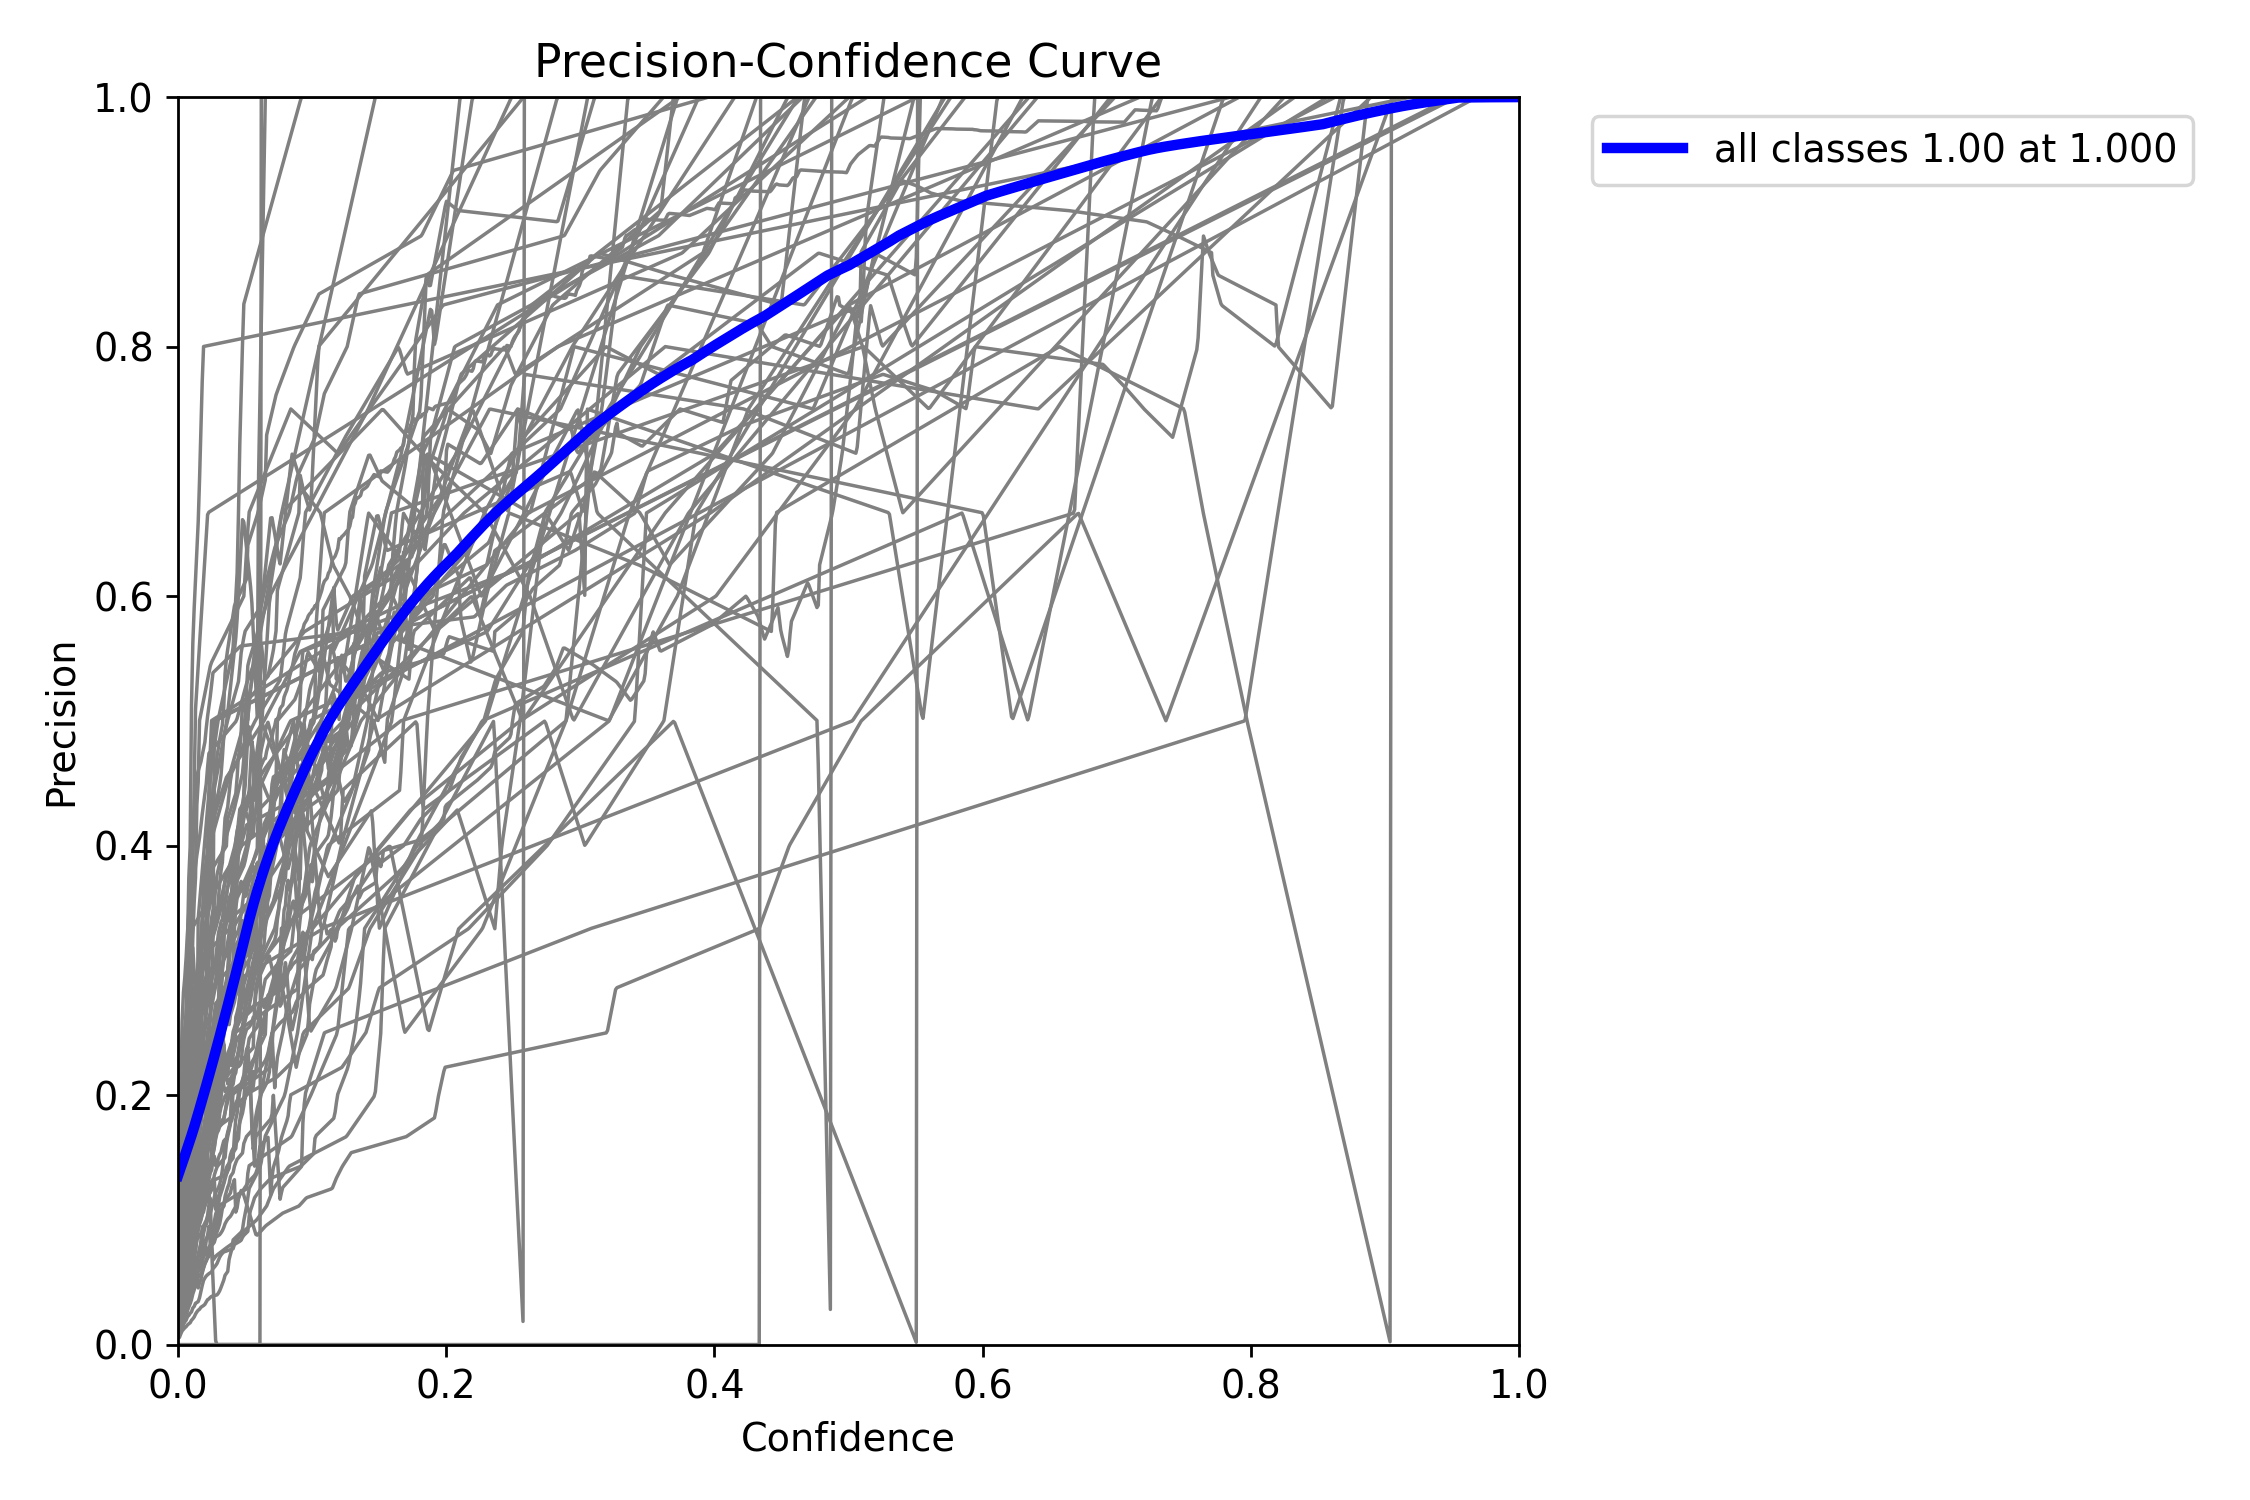

In [35]:
# 정밀도(Precision) 곡선
Image.open('runs/detect/val/BoxP_curve.png')

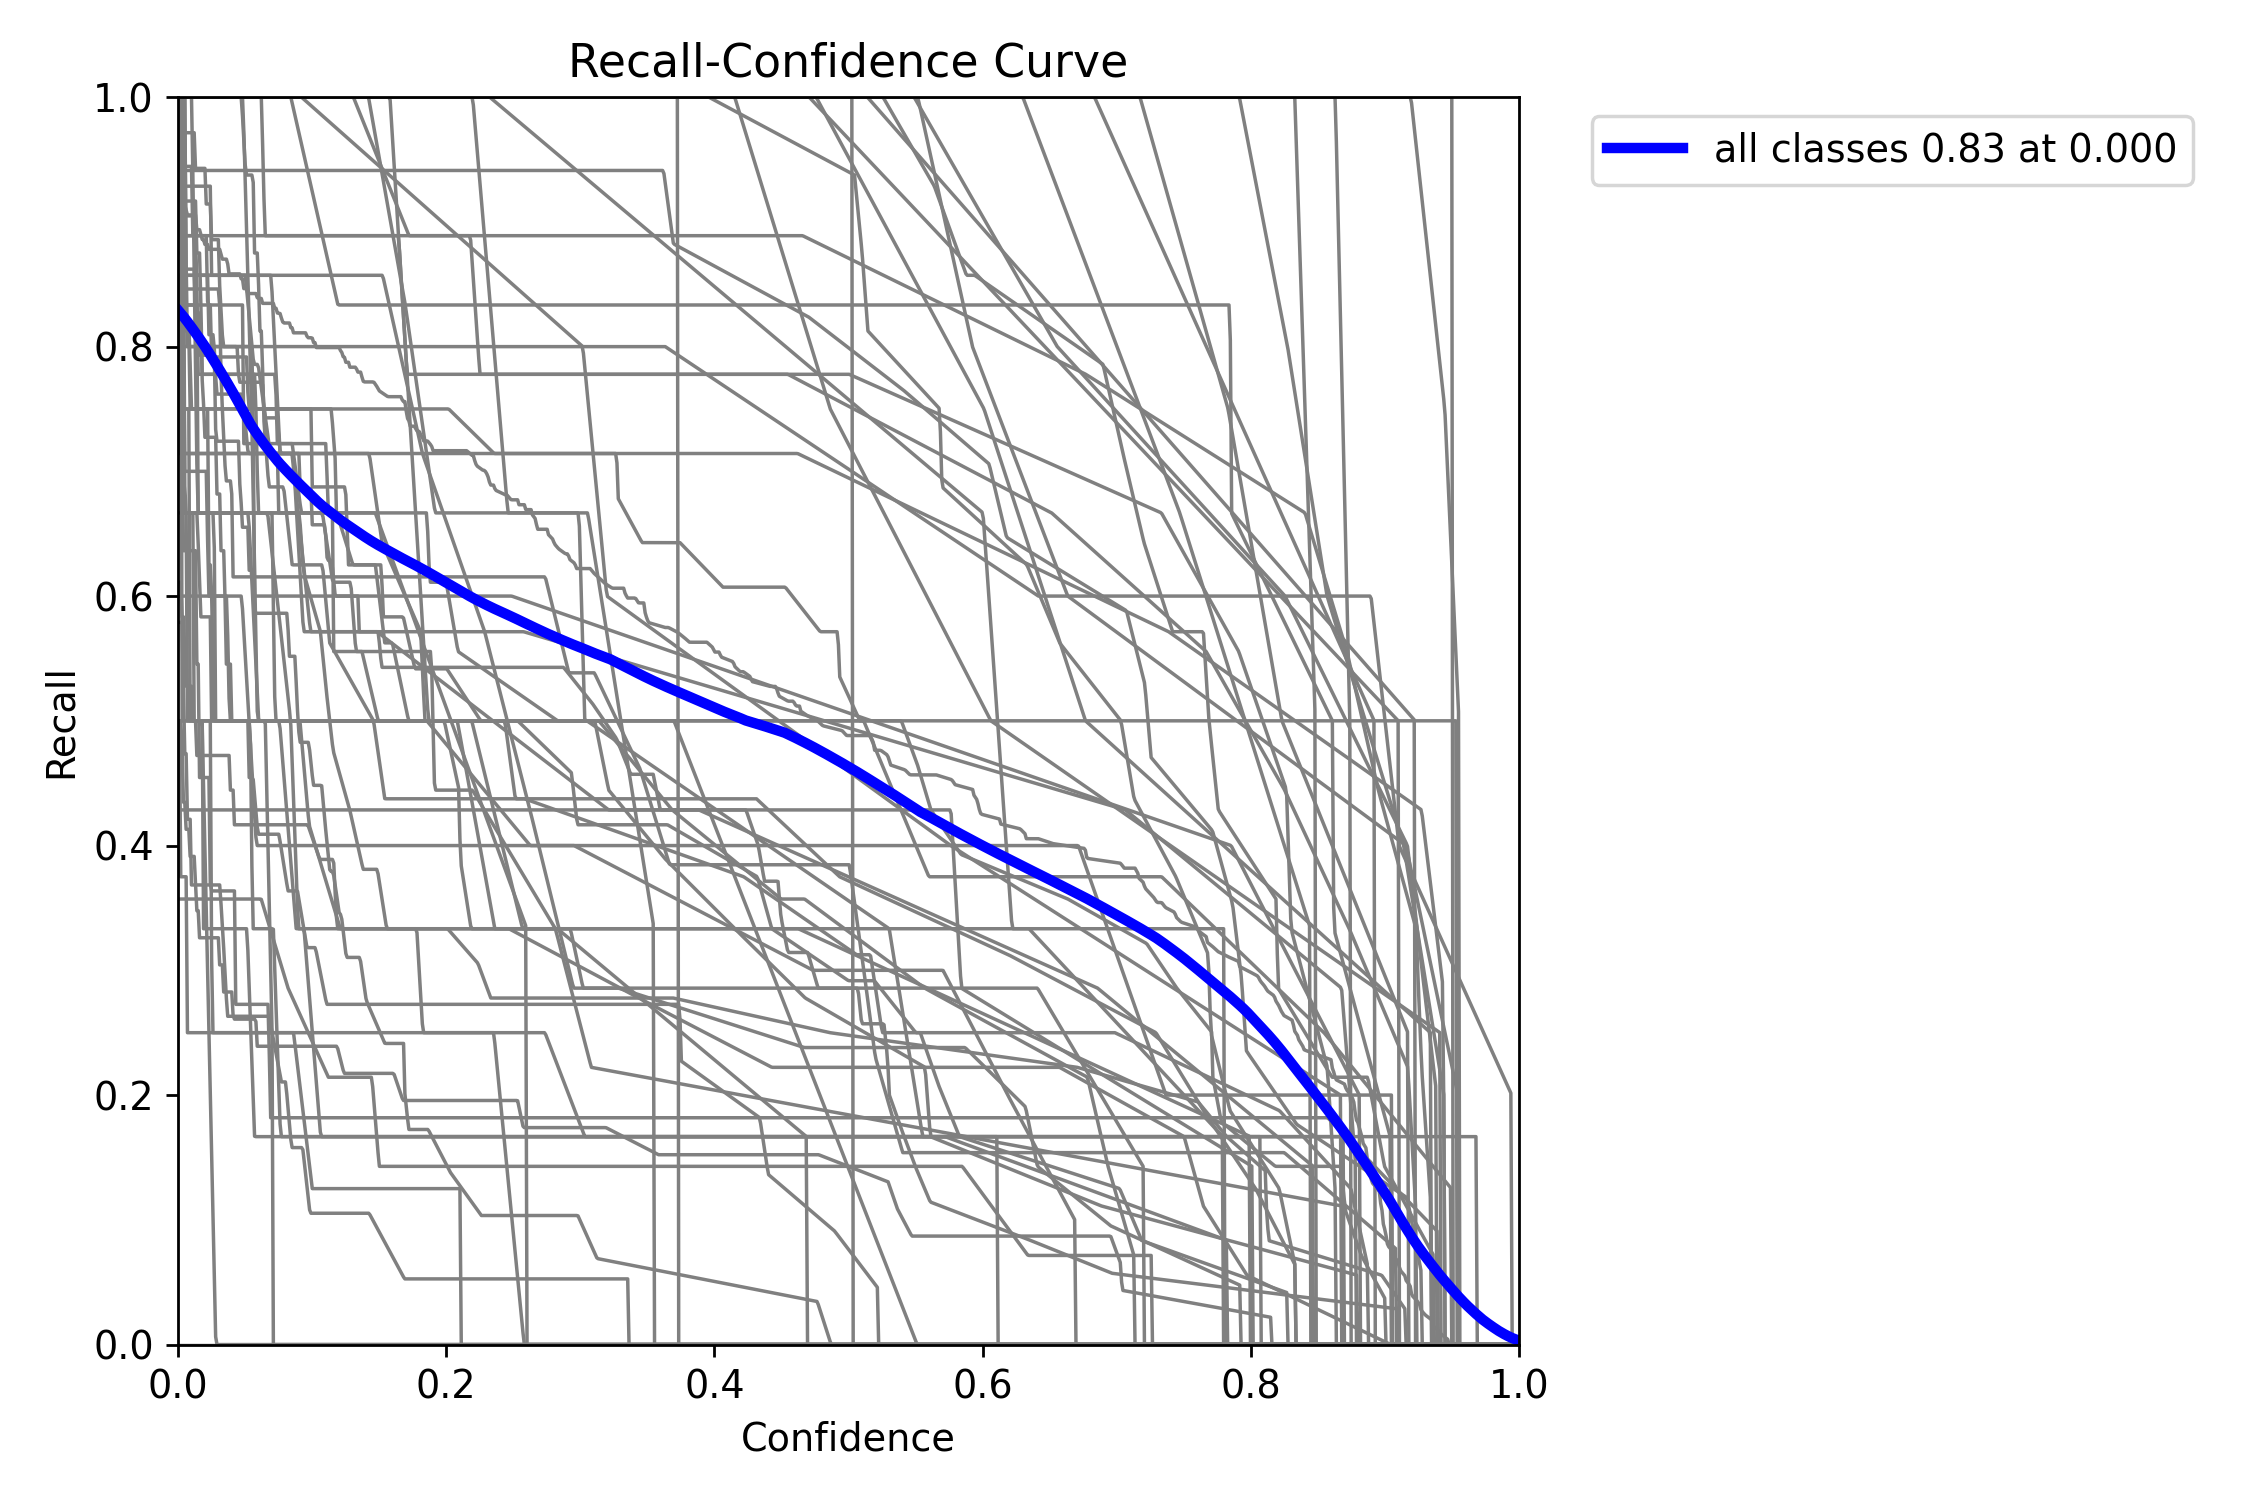

In [36]:
# 재현도(Recall) 곡선
Image.open('runs/detect/val/BoxR_curve.png')

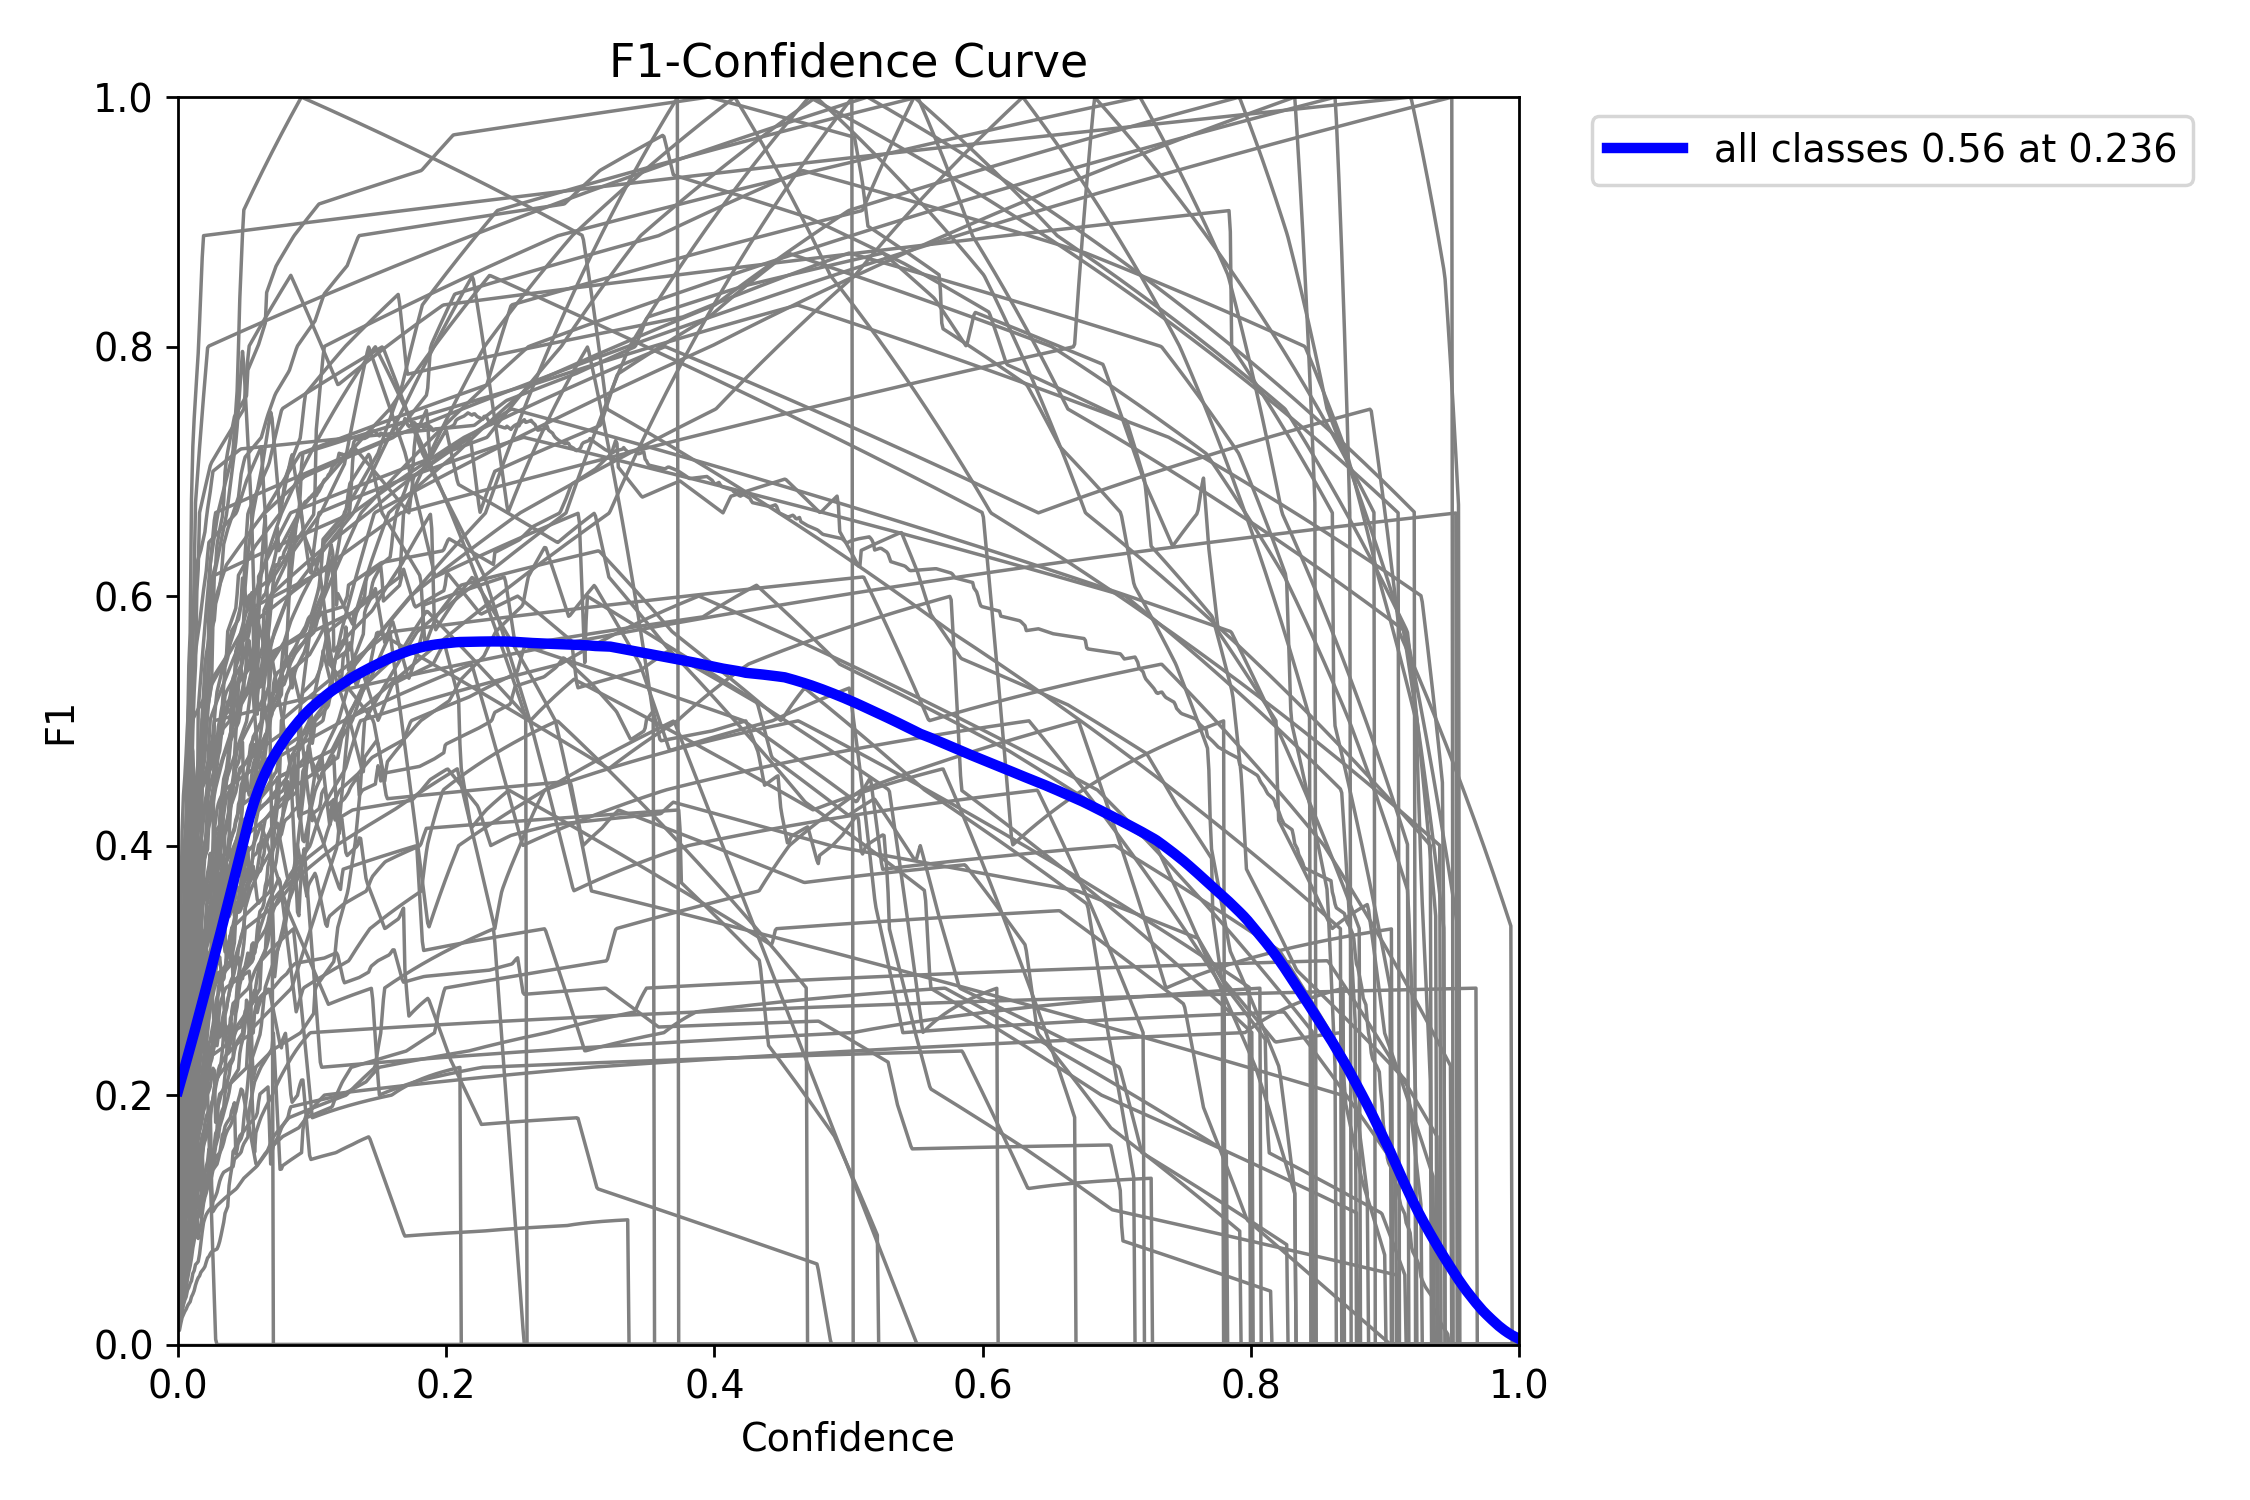

In [37]:
# F1 곡선
Image.open('runs/detect/val/BoxF1_curve.png')

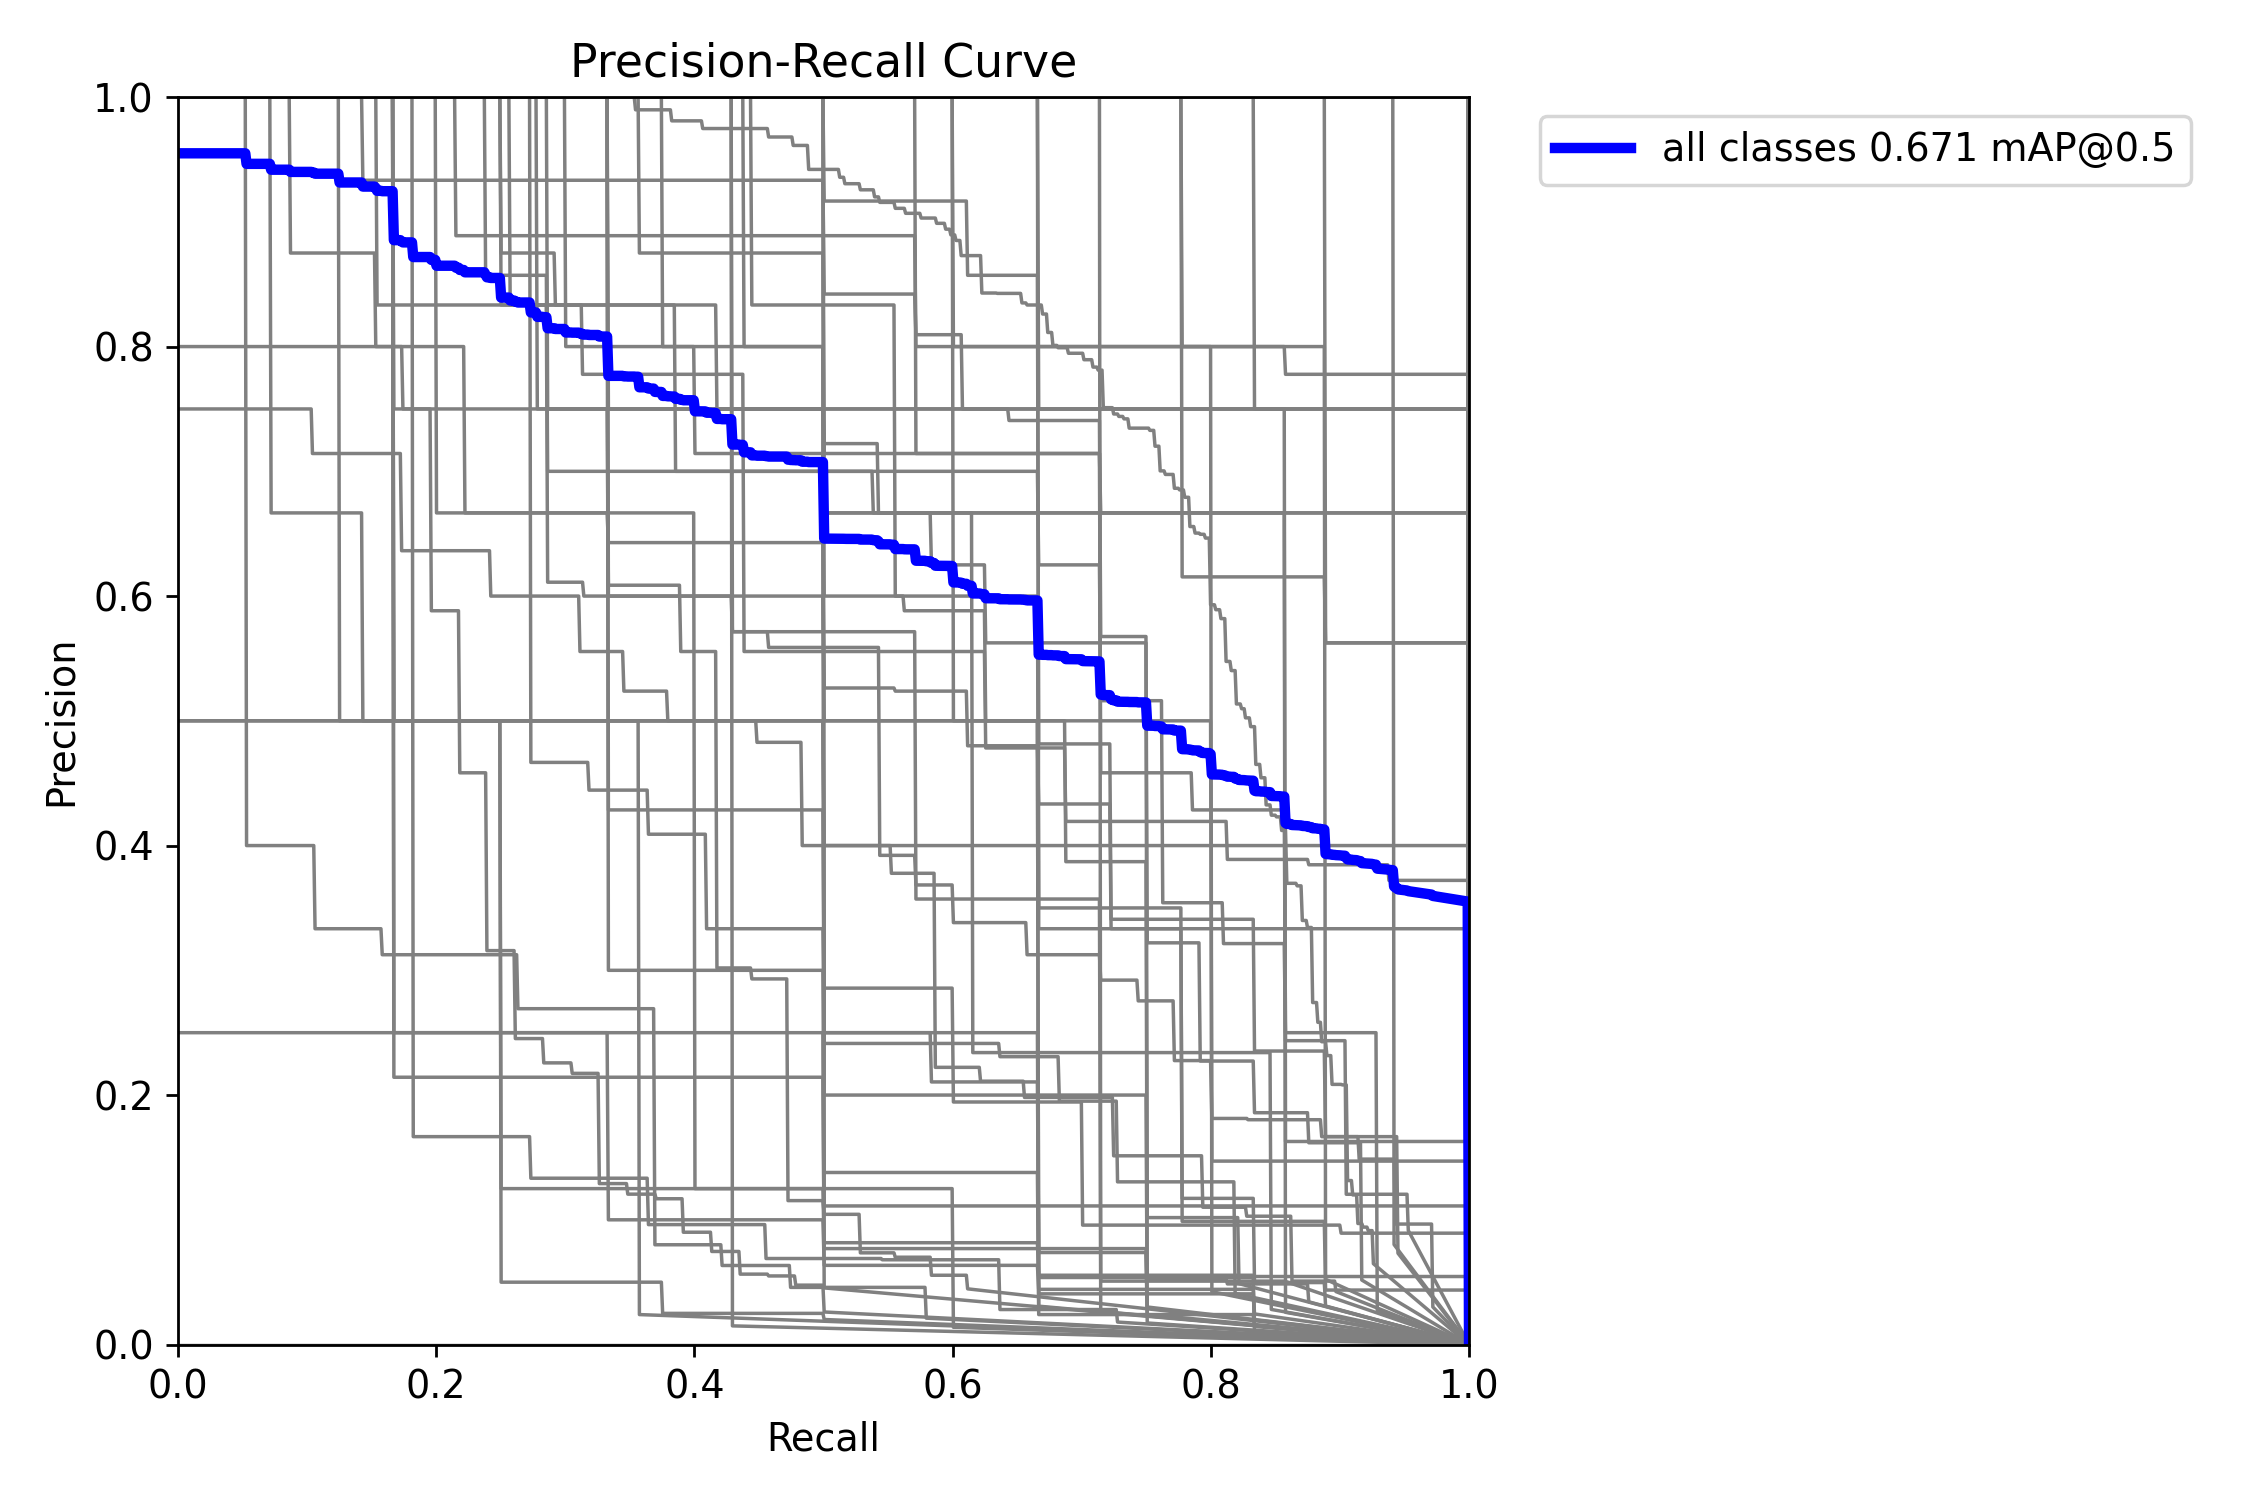

In [38]:
# PR 곡선
Image.open('runs/detect/val/BoxPR_curve.png')